<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/11_sql_procurement_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Connect to an SQLite database (creates procurement.db on disk)
conn = sqlite3.connect("procurement.db")
cursor = conn.cursor()

# 1. Create Tables
cursor.execute(
    """
CREATE TABLE IF NOT EXISTS vendors (
    vendor_id INTEGER PRIMARY KEY,
    vendor_name TEXT NOT NULL,
    vendor_category TEXT NOT NULL,
    msme_registered INTEGER NOT NULL
);
"""
)

cursor.execute(
    """
CREATE TABLE IF NOT EXISTS procurement_contracts (
    contract_id INTEGER PRIMARY KEY,
    department TEXT NOT NULL,
    vendor_id INTEGER NOT NULL,
    tender_value_cr REAL NOT NULL,
    delivery_status TEXT NOT NULL,
    delay_days INTEGER NOT NULL,
    FOREIGN KEY (vendor_id) REFERENCES vendors(vendor_id)
);
"""
)

# 2. Insert Vendor Registry Data
vendors_data = [
    (101, "Alpha Infra Corp", "Large Enterprise", 0),
    (102, "Sahyadri Tech Solutions", "MSME", 1),
    (103, "Bharat Steel & Power", "Large Enterprise", 0),
    (104, "Vanguard Medical Supplies", "MSME", 1),
    (105, "Deccan Logistics Ltd", "Large Enterprise", 0),
    (106, "Greenfield Urban Works", "MSME", 1),
]

cursor.executemany(
    "INSERT OR REPLACE INTO vendors VALUES (?, ?, ?, ?);", vendors_data
)

# 3. Insert Procurement Contracts Data
contracts_data = [
    (1001, "Railways", 101, 145.5, "Completed", 12),
    (1002, "Health", 104, 38.2, "Completed", 0),
    (1003, "Road Transport", 101, 210.0, "Delayed", 45),
    (1004, "Education", 102, 14.5, "Completed", 5),
    (1005, "Railways", 103, 95.0, "Delayed", 30),
    (1006, "Health", 104, 42.0, "Completed", 0),
    (1007, "Urban Affairs", 106, 28.5, "Completed", 8),
    (1008, "Road Transport", 105, 88.0, "Completed", 15),
    (1009, "Railways", 101, 120.0, "Delayed", 60),
    (1010, "Urban Affairs", 106, 31.0, "Delayed", 22),
    (1011, "Education", 102, 18.0, "Completed", 0),
    (1012, "Road Transport", 103, 110.0, "Completed", 10),
]

cursor.executemany(
    "INSERT OR REPLACE INTO procurement_contracts VALUES (?, ?, ?, ?, ?, ?);",
    contracts_data,
)
conn.commit()

print("SQLite database 'procurement.db' created and populated successfully.")

SQLite database 'procurement.db' created and populated successfully.


In [2]:
# Query 1: Vendor Exposure & Risk Analysis using SQL JOIN and Aggregation
vendor_sql = """
SELECT
    v.vendor_name,
    v.vendor_category,
    CASE WHEN v.msme_registered = 1 THEN 'Yes' ELSE 'No' END AS is_msme,
    COUNT(c.contract_id) AS total_contracts,
    ROUND(SUM(c.tender_value_cr), 2) AS total_allocated_cr,
    ROUND(AVG(c.delay_days), 1) AS avg_delay_days,
    SUM(CASE WHEN c.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_contracts
FROM vendors v
JOIN procurement_contracts c ON v.vendor_id = c.vendor_id
GROUP BY v.vendor_id, v.vendor_name, v.vendor_category, v.msme_registered
ORDER BY total_allocated_cr DESC;
"""

df_vendor_summary = pd.read_sql_query(vendor_sql, conn)

print("--- SQL Query Result: Vendor Risk & Allocation ---")
print(df_vendor_summary)

--- SQL Query Result: Vendor Risk & Allocation ---
                 vendor_name   vendor_category is_msme  total_contracts  \
0           Alpha Infra Corp  Large Enterprise      No                3   
1       Bharat Steel & Power  Large Enterprise      No                2   
2       Deccan Logistics Ltd  Large Enterprise      No                1   
3  Vanguard Medical Supplies              MSME     Yes                2   
4     Greenfield Urban Works              MSME     Yes                2   
5    Sahyadri Tech Solutions              MSME     Yes                2   

   total_allocated_cr  avg_delay_days  delayed_contracts  
0               475.5            39.0                  2  
1               205.0            20.0                  1  
2                88.0            15.0                  0  
3                80.2             0.0                  0  
4                59.5            15.0                  1  
5                32.5             2.5                  0  


In [3]:
dept_sql = """
SELECT
    c.department,
    ROUND(SUM(c.tender_value_cr), 2) AS total_spend_cr,
    ROUND(SUM(CASE WHEN v.msme_registered = 1 THEN c.tender_value_cr ELSE 0 END), 2) AS msme_spend_cr,
    ROUND(
        (SUM(CASE WHEN v.msme_registered = 1 THEN c.tender_value_cr ELSE 0 END) / SUM(c.tender_value_cr)) * 100,
        2
    ) AS msme_share_pct
FROM procurement_contracts c
JOIN vendors v ON c.vendor_id = v.vendor_id
GROUP BY c.department
ORDER BY total_spend_cr DESC;
"""

df_dept_audit = pd.read_sql_query(dept_sql, conn)

print("--- Departmental MSME Procurement Share Audit ---")
print(df_dept_audit)

--- Departmental MSME Procurement Share Audit ---
       department  total_spend_cr  msme_spend_cr  msme_share_pct
0  Road Transport           408.0            0.0             0.0
1        Railways           360.5            0.0             0.0
2          Health            80.2           80.2           100.0
3   Urban Affairs            59.5           59.5           100.0
4       Education            32.5           32.5           100.0


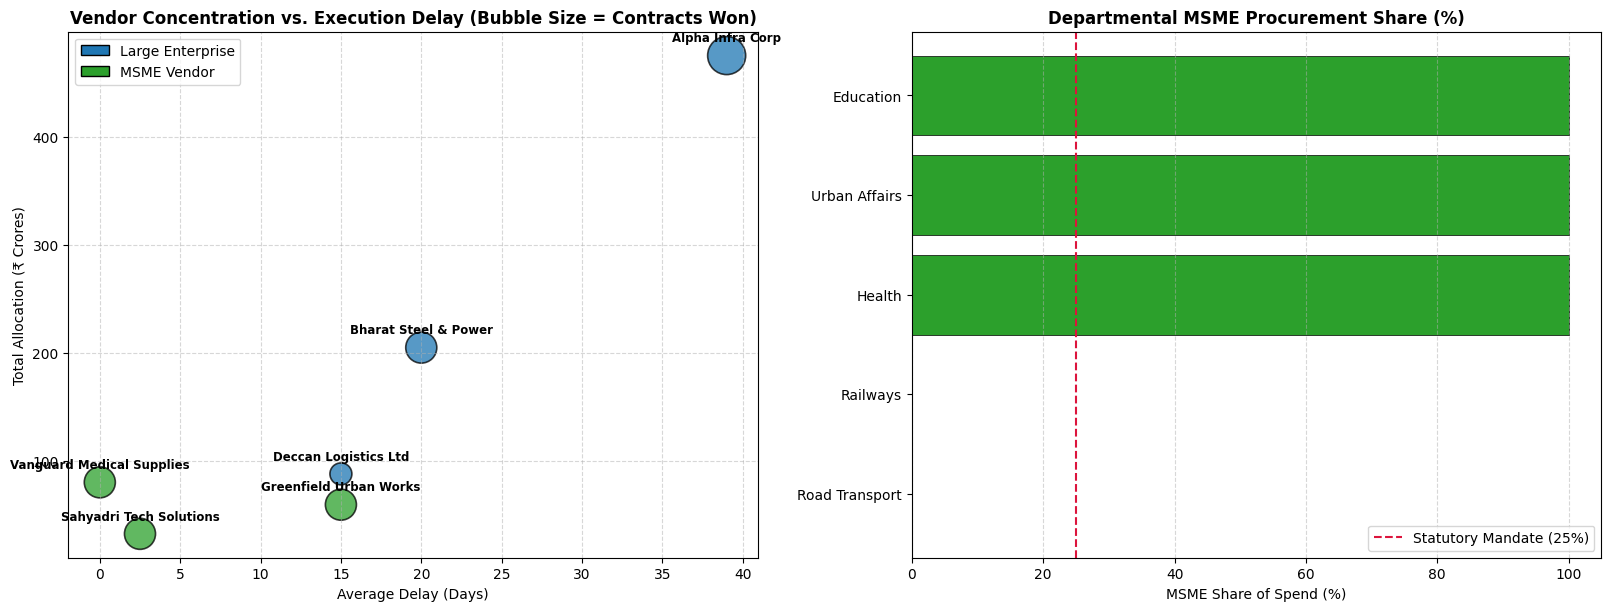

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Vendor Allocation vs. Average Delivery Delay ---
scatter_colors = [
    "#1f77b4" if cat == "Large Enterprise" else "#2ca02c"
    for cat in df_vendor_summary["vendor_category"]
]

scatter = ax1.scatter(
    df_vendor_summary["avg_delay_days"],
    df_vendor_summary["total_allocated_cr"],
    s=df_vendor_summary["total_contracts"] * 250,  # Size = number of contracts
    c=scatter_colors,
    alpha=0.75,
    edgecolor="black",
    linewidth=1.2,
)

for _, row in df_vendor_summary.iterrows():
    ax1.annotate(
        row["vendor_name"],
        (row["avg_delay_days"], row["total_allocated_cr"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8.5,
        weight="bold",
    )

ax1.set_title(
    "Vendor Concentration vs. Execution Delay (Bubble Size = Contracts Won)",
    fontsize=12,
    weight="bold",
)
ax1.set_xlabel("Average Delay (Days)")
ax1.set_ylabel("Total Allocation (₹ Crores)")
ax1.grid(True, linestyle="--", alpha=0.5)

# Custom legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#1f77b4", edgecolor="black", label="Large Enterprise"),
    Patch(facecolor="#2ca02c", edgecolor="black", label="MSME Vendor"),
]
ax1.legend(handles=legend_elements, loc="upper left")

# --- Chart 2: Departmental MSME Mandate Compliance (%) ---
sorted_dept = df_dept_audit.sort_values(by="msme_share_pct")
colors = [
    "#2ca02c" if share >= 25.0 else "#d62728"
    for share in sorted_dept["msme_share_pct"]
]

ax2.barh(
    sorted_dept["department"],
    sorted_dept["msme_share_pct"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)
ax2.axvline(
    25.0,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Statutory Mandate (25%)",
)

ax2.set_title(
    "Departmental MSME Procurement Share (%)", fontsize=12, weight="bold"
)
ax2.set_xlabel("MSME Share of Spend (%)")
ax2.set_xlim(0, 105)
ax2.legend(loc="lower right")
ax2.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Close SQLite connection cleanly
conn.close()